<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week4/Day3/ExercisesXP_Heart_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [37]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [34]:
import zipfile
import glob

# Extract the dataset
ZIP_PATH = '/content/Heart Disease Prediction Dataset.zip'
EXTRACT_DIR = 'heart_ds'
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# List and load CSV
csv_files = glob.glob(f'{EXTRACT_DIR}/*.csv')
csv_path = csv_files[0] if csv_files else None
df = pd.read_csv(csv_path)

# Correct target based on inspection
target = 'heart disease'

# Map labels 1,2 to 0,1 for compatibility
df[target] = df[target] - 1

# Split features and target
X = df.drop(columns=[target])
y = df[target]

# Train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f'Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}')

Training set size: 216, Test set size: 54


### Basic visual checks

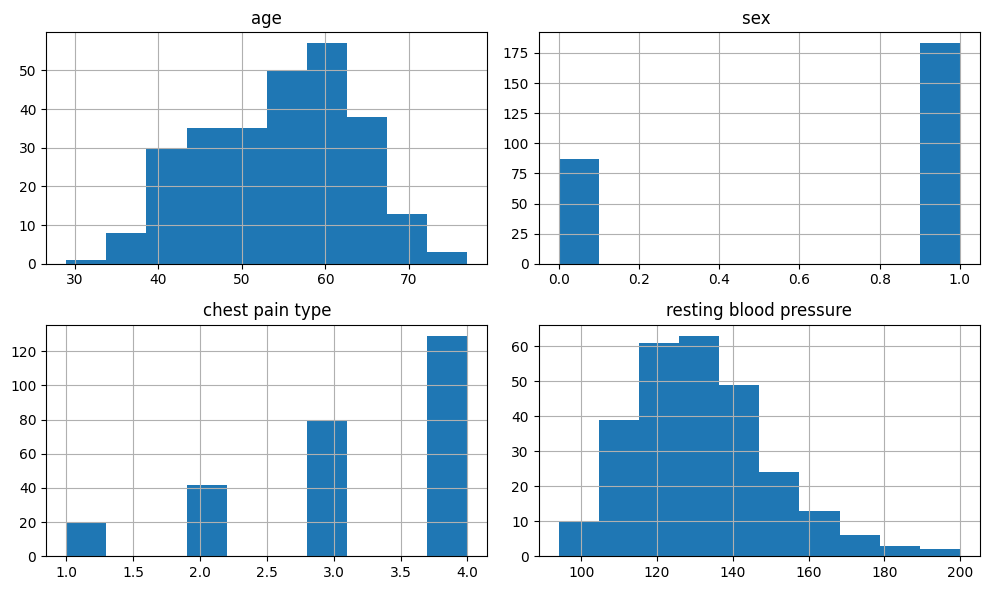

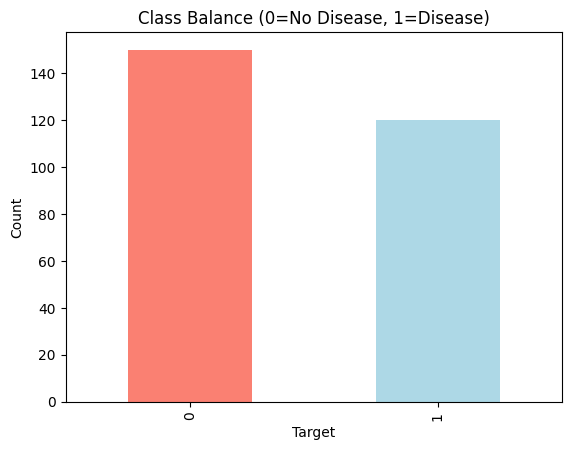

In [24]:
# Re-run EDA
numeric_cols = df.select_dtypes(include=[np.number]).columns[:4]
df[numeric_cols].hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

df[target].value_counts().plot(kind='bar', color=['salmon', 'lightblue'])
plt.title('Class Balance (0=No Disease, 1=Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

## Preprocessing pipeline

In [25]:
# Re-run Preprocessing
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## Helper - evaluation function

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

def eval_and_report(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }

    print(f'--- {name} ---')
    for k, v in metrics.items():
        print(f'{k}: {v:.4f}')

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax[0], cmap='Blues')
    ax[0].set_title(f'Confusion Matrix - {name}')

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        metrics['auc'] = roc_auc_score(y_test, y_proba)
        ax[1].plot(fpr, tpr, label=f'AUC = {metrics["auc"]:.4f}')
        ax[1].plot([0, 1], [0, 1], 'k--')
        ax[1].set_title(f'ROC Curve - {name}')
        ax[1].legend()

    plt.show()
    return metrics

## Exercise 2 - Logistic Regression without Grid Search

--- LR no grid ---
accuracy: 0.8519
precision: 0.7857
recall: 0.9167
f1: 0.8462


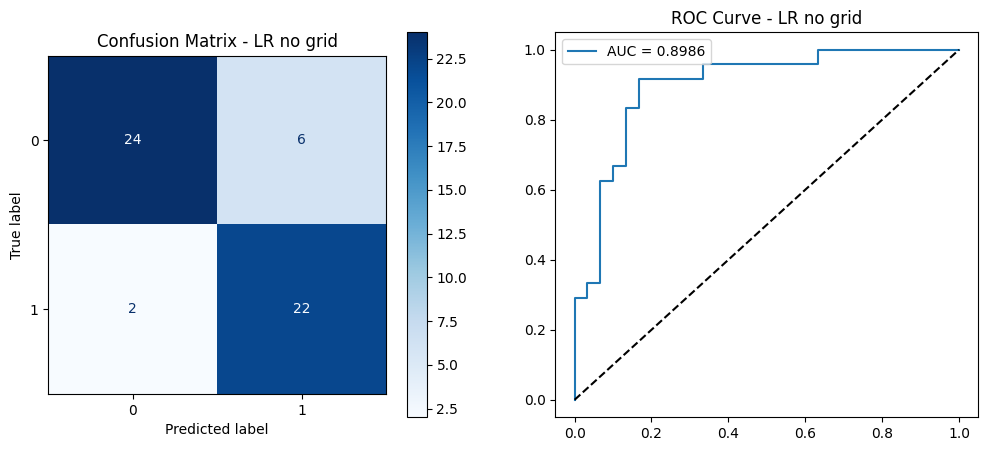

In [26]:
pipe_lr = Pipeline([('pre', pre), ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))])
pipe_lr.fit(X_train, y_train)
lr_no_gs_metrics = eval_and_report('LR no grid', pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

--- LR grid ---
accuracy: 0.8519
precision: 0.7857
recall: 0.9167
f1: 0.8462


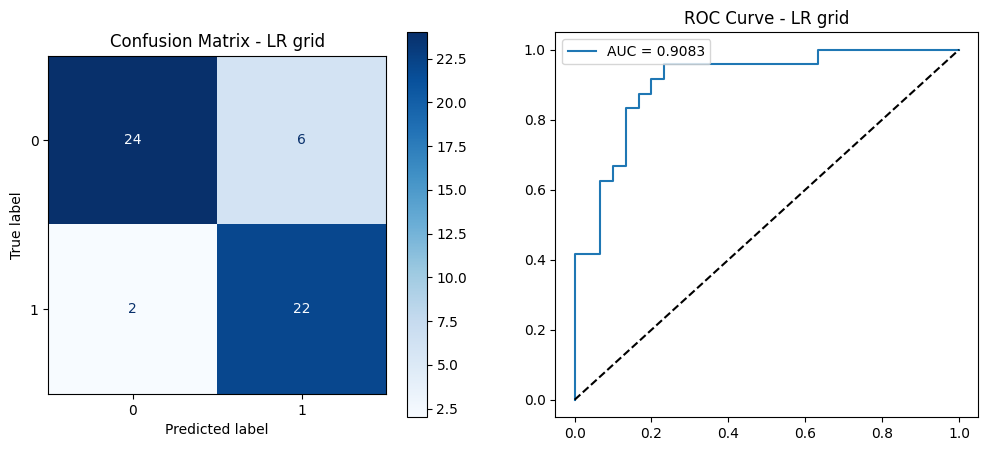

In [27]:
param_grid = {'lr__C': [0.1, 1, 10], 'lr__penalty': ['l1', 'l2']}
grid_lr = GridSearchCV(pipe_lr, param_grid, cv=5, scoring='f1')
grid_lr.fit(X_train, y_train)
lr_gs_metrics = eval_and_report('LR grid', grid_lr.best_estimator_, X_test, y_test)

## Exercise 4 - SVM without Grid Search

--- SVM no grid ---
accuracy: 0.8148
precision: 0.7692
recall: 0.8333
f1: 0.8000


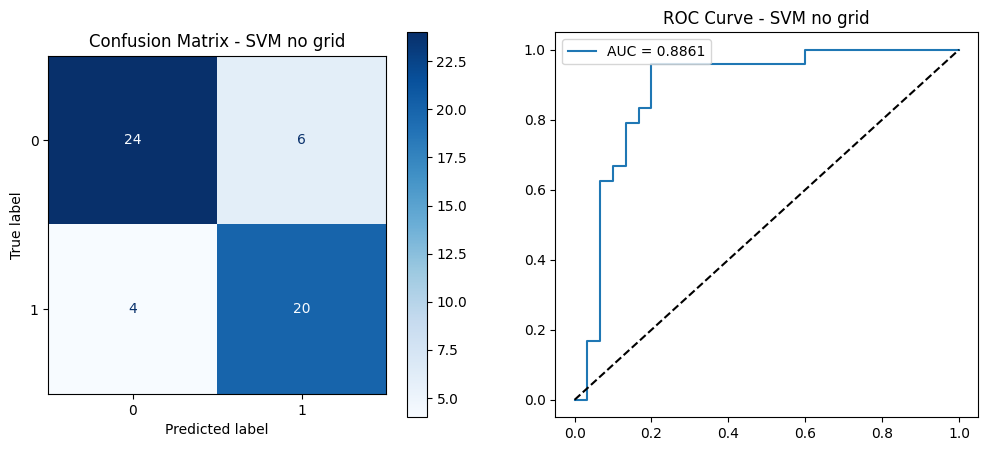

In [28]:
pipe_svm = Pipeline([('pre', pre), ('svm', SVC(probability=True, random_state=RANDOM_STATE))])
pipe_svm.fit(X_train, y_train)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search

--- SVM grid ---
accuracy: 0.8519
precision: 0.8077
recall: 0.8750
f1: 0.8400


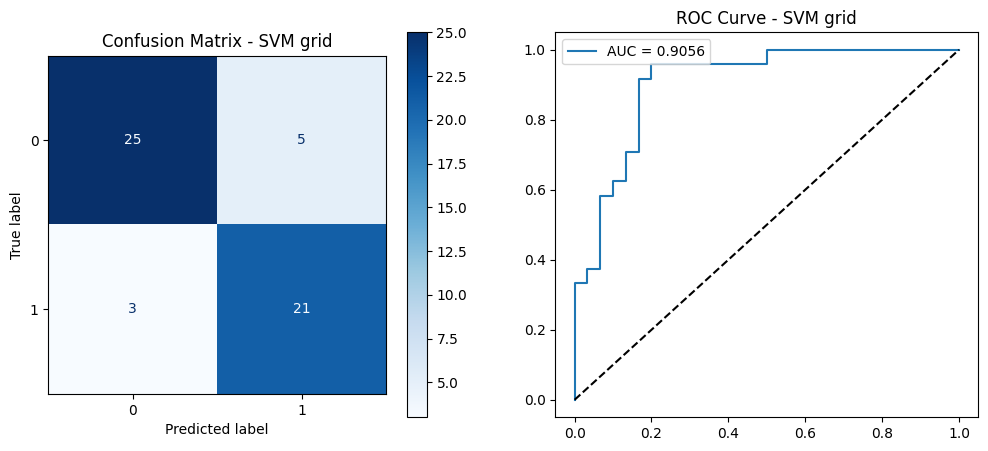

In [29]:
svm_param_grid = {'svm__C': [0.1, 1, 10], 'svm__kernel': ['rbf', 'linear']}
grid_svm = GridSearchCV(pipe_svm, svm_param_grid, cv=5, scoring='f1')
grid_svm.fit(X_train, y_train)
svm_gs_metrics = eval_and_report('SVM grid', grid_svm.best_estimator_, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search

--- XGB no grid ---
accuracy: 0.8148
precision: 0.7692
recall: 0.8333
f1: 0.8000


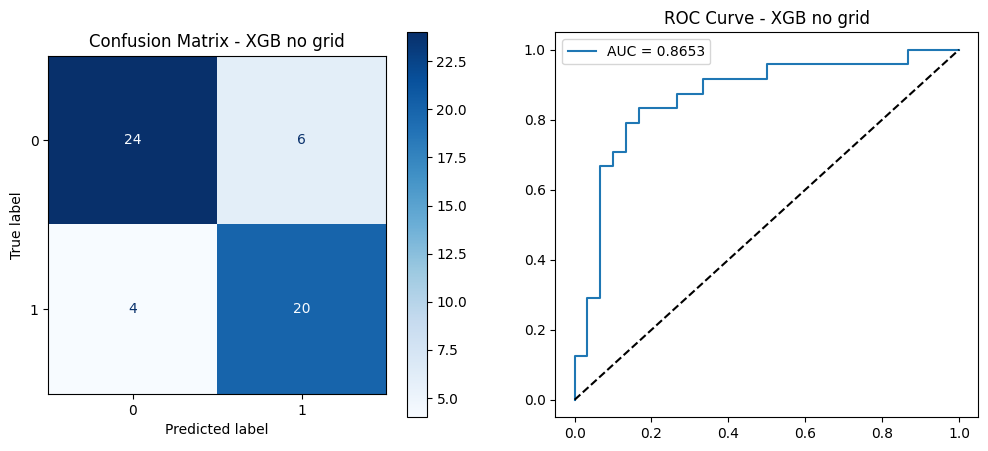

In [30]:
if XGBClassifier:
    pipe_xgb = Pipeline([('pre', pre), ('xgb', XGBClassifier(random_state=RANDOM_STATE))])
    pipe_xgb.fit(X_train, y_train)
    xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)
else:
    xgb_no_metrics = {}

## Exercise 7 - XGBoost with Grid Search

--- XGB grid ---
accuracy: 0.8148
precision: 0.7692
recall: 0.8333
f1: 0.8000


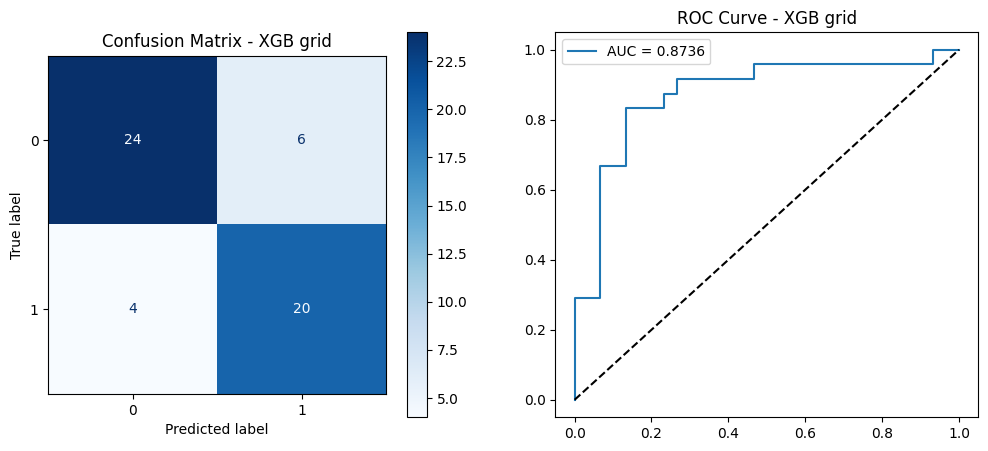

In [31]:
if XGBClassifier:
    xgb_param_grid = {'xgb__n_estimators': [100, 200], 'xgb__learning_rate': [0.01, 0.1]}
    grid_xgb = GridSearchCV(pipe_xgb, xgb_param_grid, cv=5, scoring='f1')
    grid_xgb.fit(X_train, y_train)
    xgb_gs_metrics = eval_and_report('XGB grid', grid_xgb.best_estimator_, X_test, y_test)
else:
    xgb_gs_metrics = {}

## Compare models

In [32]:
summary = {'LR no grid': lr_no_gs_metrics, 'LR grid': lr_gs_metrics, 'SVM no grid': svm_no_metrics, 'SVM grid': svm_gs_metrics, 'XGB no grid': xgb_no_metrics, 'XGB grid': xgb_gs_metrics}
summary_df = pd.DataFrame.from_dict(summary, orient='index')
display(summary_df)

,accuracy,precision,recall,f1,auc
LR no grid,0.851852,0.785714,0.916667,0.846154,0.898611
LR grid,0.851852,0.785714,0.916667,0.846154,0.908333
SVM no grid,0.814815,0.769231,0.833333,0.800000,0.886111
SVM grid,0.851852,0.807692,0.875000,0.840000,0.905556
XGB no grid,0.814815,0.769231,0.833333,0.800000,0.865278
XGB grid,0.814815,0.769231,0.833333,0.800000,0.873611
